In [1]:
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
ensure_dirs(dirs+"data/esm_data")
ensure_dirs(dirs+"data/pretrained")
csv_to_fasta(dirs+"data/split50.csv", dirs+"data/split50.fasta")
csv_to_fasta(dirs+"data/new.csv", dirs+"data/new.fasta")

In [ ]:
import math
mu, sigma = .10, .02 # mean and standard deviation
s = np.random.normal(mu, sigma, 1)
mut_rate = s[0]
times = math.ceil(1000* mut_rate)

In [ ]:
import math
def mutate(seq: str, position: int) -> str:
    seql = seq[ : position]
    seqr = seq[position+1 : ]
    seq = seql + '*' + seqr
    return seq

def mask_sequences(single_id, csv_name, fasta_name) :
    csv_file = open(dirs + 'data/'+ csv_name + '.csv')
    csvreader = csv.reader(csv_file, delimiter = '\t')
    output_fasta = open(dirs + 'data/' + fasta_name + '.fasta','w')
    single_id = set(single_id)
    for i, rows in enumerate(csvreader):
        if rows[0] in single_id:
            for j in range(10):
                seq = rows[2].strip()
                mu, sigma = .10, .02 # mean and standard deviation
                s = np.random.normal(mu, sigma, 1)
                mut_rate = s[0]
                times = math.ceil(len(seq) * mut_rate)
                for k in range(times):
                    position = random.randint(1 , len(seq) - 1)
                    seq = mutate(seq, position)
                seq = seq.replace('*', '<mask>')
                output_fasta.write('>' + rows[0] + '_' + str(j) + '\n')
                output_fasta.write(seq + '\n')

def mutate_single_seq_ECs(train_file):
    id_ec, ec_id =  get_ec_id_dict(dirs + 'data/' + train_file + '.csv')
    single_ec = set()
    for ec in ec_id.keys():
        if len(ec_id[ec]) == 1:
            single_ec.add(ec)
    single_id = set()
    for id in id_ec.keys():
        for ec in id_ec[id]:
            if ec in single_ec:
                single_id.add(id)
                break
    print("Number of EC numbers with only one sequences:",len(single_ec))
    print("Number of single-seq EC number sequences need to mutate: ",len(single_id))
    print("Number of single-seq EC numbers already mutated: ", len(single_ec) - len(single_id))
    mask_sequences(single_id, train_file, train_file+'_single_seq_ECs')
    fasta_name = train_file+'_single_seq_ECs'
    return fasta_name


In [ ]:


train_file = "RepFunFold"

train_fasta_file = mutate_single_seq_ECs(train_file)



Number of EC numbers with only one sequences: 115
Number of single-seq EC number sequences need to mutate:  115
Number of single-seq EC numbers already mutated:  0


In [ ]:
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split50' + '.csv')

In [ ]:
length_key = []
for key in ec_id.keys():
    length_key.append(len(ec_id[key]))

In [ ]:
np.sort(length_key)[:1500]

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
"data/split_con_augu_50.csv"

In [ ]:
import torch
from tqdm import tqdm
import torch.nn.functional as F
def get_cluster_center(model_emb, ec_id_dict):
    cluster_center_model = {}
    id_counter = 0
    with torch.no_grad():
        for ec in tqdm(list(ec_id_dict.keys())):
            ids_for_query = list(ec_id_dict[ec])
            id_counter_prime = id_counter + len(ids_for_query)
            emb_cluster = model_emb[id_counter: id_counter_prime]
            print(emb_cluster)
            cluster_center = emb_cluster.mean(dim=0)
            cluster_center_model[ec] = cluster_center.detach().cpu()
            id_counter = id_counter_prime
    return cluster_center_model


def dist_map_helper_dot(keys1, lookup1, keys2, lookup2):
    dist = {}
    lookup1 = F.normalize(lookup1, dim=-1, p=2)
    lookup2 = F.normalize(lookup2, dim=-1, p=2)
    for i, key1 in tqdm(enumerate(keys1)):
        current = lookup1[i].unsqueeze(0)
        dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm**2
        #dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm.detach().cpu().numpy()
        dist[key1] = {}
        for j, key2 in enumerate(keys2):
            dist[key1][key2] = dist_norm[j]
    return dist


def dist_map_helper(keys1, lookup1, keys2, lookup2):
    dist = {}
    for i, key1 in tqdm(enumerate(keys1)):
        current = lookup1[i].unsqueeze(0)
        dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm.detach().cpu().numpy()
        dist[key1] = {}
        for j, key2 in enumerate(keys2):
            dist[key1][key2] = dist_norm[j]
    return dist


def get_dist_map(ec_id_dict, esm_emb, device, dtype, model=None, dot=False):
    '''
    Get the distance map for training, size of (N_EC_train, N_EC_train)
    between all possible pairs of EC cluster centers
    '''
    # inference all queries at once to get model embedding
    if model is not None:
        model_emb,_ = model(esm_emb.to(device=device, dtype=dtype))
    else:
        # the first distance map before training comes from ESM
        model_emb = esm_emb
    # calculate cluster center by averaging all embeddings in one EC
    cluster_center_model = get_cluster_center(model_emb, ec_id_dict)
    # organize cluster centers in a matrix
    total_ec_n, out_dim = len(ec_id_dict.keys()), model_emb.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    # calculate pairwise distance map between total_ec_n * total_ec_n pairs
    print(f'Calculating distance map, number of unique EC is {total_ec_n}')
    if dot:
        model_dist = dist_map_helper_dot(ecs, model_lookup, ecs, model_lookup)
    else:
        model_dist = dist_map_helper(ecs, model_lookup, ecs, model_lookup)
    return model_dist


def get_dist_map_fold(ec_id_dict, esm_emb, device, dtype, model=None, dot=False):
    '''
    Get the distance map for training, size of (N_EC_train, N_EC_train)
    between all possible pairs of EC cluster centers
    '''
    # inference all queries at once to get model embedding
    if model is not None:
        _, model_emb = model(esm_emb.to(device=device, dtype=dtype))
    else:
        # the first distance map before training comes from ESM
        model_emb = esm_emb
    # calculate cluster center by averaging all embeddings in one EC
    cluster_center_model = get_cluster_center(model_emb, ec_id_dict)
    # organize cluster centers in a matrix
    total_ec_n, out_dim = len(ec_id_dict.keys()), model_emb.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    # calculate pairwise distance map between total_ec_n * total_ec_n pairs
    print(f'Calculating distance map, number of unique EC is {total_ec_n}')
    if dot:
        model_dist = dist_map_helper_dot(ecs, model_lookup, ecs, model_lookup)
    else:
        model_dist = dist_map_helper(ecs, model_lookup, ecs, model_lookup)
    return model_dist



def get_dist_map_test(model_emb_train, model_emb_test,
                      ec_id_dict_train, id_ec_test,
                      device, dtype, dot=False):
    '''
    Get the pair-wise distance map for test queries and train EC cluster centers
    map is of size of (N_test_ids, N_EC_train)
    '''
    print("The embedding sizes for train and test:",
          model_emb_train.size(), model_emb_test.size())
    # get cluster center for all EC appeared in training set
    cluster_center_model = get_cluster_center(
        model_emb_train, ec_id_dict_train)
    total_ec_n, out_dim = len(ec_id_dict_train.keys()), model_emb_train.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    # calculate distance map between n_query_test * total_ec_n (training) pairs
    ids = list(id_ec_test.keys())
    print(f'Calculating eval distance map, between {len(ids)} test ids '
          f'and {total_ec_n} train EC cluster centers')
    if dot:
        eval_dist = dist_map_helper_dot(ids, model_emb_test, ecs, model_lookup)
    else:
        eval_dist = dist_map_helper(ids, model_emb_test, ecs, model_lookup)
    return eval_dist


def get_random_nk_dist_map(emb_train, rand_nk_emb_train,
                           ec_id_dict_train, rand_nk_ids,
                           device, dtype, dot=False):
    '''
    Get the pair-wise distance map between
    randomly chosen nk ids from training and all EC cluster centers
    map is of size of (nk, N_EC_train)
    '''
    cluster_center_model = get_cluster_center(emb_train, ec_id_dict_train)
    total_ec_n, out_dim = len(ec_id_dict_train.keys()), emb_train.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    if dot:
        random_nk_dist_map = dist_map_helper_dot(
            rand_nk_ids, rand_nk_emb_train, ecs, model_lookup)
    else:
        random_nk_dist_map = dist_map_helper(
            rand_nk_ids, rand_nk_emb_train, ecs, model_lookup)
    return random_nk_dist_map

class Triplet_dataset_with_mine_EC(torch.utils.data.Dataset):

    def __init__(self, id_ec, ec_id, mine_neg, id_fold, fold_id, mine_neg_fold):
        self.id_ec = id_ec
        self.ec_id = ec_id

        self.id_fold = id_fold
        self.fold_id = fold_id


        self.full_list = []
        self.mine_neg = mine_neg

        self.mine_neg_fold = mine_neg_fold
        for ec in ec_id.keys():
            if '-' not in ec:
                self.full_list.append(ec)

    def __len__(self):
        return len(self.full_list)

    def format_esm(a):
        if type(a) == dict:
            a = a['mean_representations'][33]
        return a

    def __getitem__(self, index):
        anchor_ec = self.full_list[index]
        anchor = random.choice(self.ec_id[anchor_ec])
        pos = random_positive(anchor, self.id_ec, self.ec_id)
        neg = mine_negative(anchor, self.id_ec, self.ec_id, self.mine_neg)

        pos_fold = random_positive(anchor, self.id_fold, self.fold_id)
        neg_fold = mine_negative(anchor, self.id_fold, self.fold_id, self.mine_neg_fold)

       # a = torch.load(dirs+'data/esm_data/' + anchor + '.pt')
        #p = torch.load(dirs+'data/esm_data/' + pos + '.pt')
        #n = torch.load(dirs+'data/esm_data/' + neg + '.pt')

        a = load_prost5(anchor)
        p = load_prost5(pos)
        n = load_prost5(neg)

        pf = load_prost5(pos_fold)
        nf = load_prost5(neg_fold)



        return a,p,n, pf, nf


def get_dataloader(dist_map, dist_map_fold, id_ec, ec_id,id_fold, fold_id):
    params = {
        'batch_size': 6000,
        'shuffle': True
    }
    negative = mine_hard_negative(dist_map, 30)
    negative_fold = mine_hard_negative(dist_map_fold, 30)
    train_data = Triplet_dataset_with_mine_EC(id_ec, ec_id, negative,id_fold, fold_id, negative_fold)
    train_loader = torch.utils.data.DataLoader(train_data, **params)
    return train_loader











In [2]:
import torch.nn as nn
class LayerNormNet(nn.Module):
    def __init__(self, hidden_dim, out_dim, device, dtype, drop_out=0.1):
        super(LayerNormNet, self).__init__()
        self.hidden_dim1 = hidden_dim
        self.out_dim = out_dim
        self.drop_out = drop_out
        self.device = device
        self.dtype = dtype

        self.fc1 = nn.Linear(1024, hidden_dim, dtype=dtype, device=device)
        self.ln1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim,
                             dtype=dtype, device=device)
        self.ln2 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc3 = nn.Linear(hidden_dim, out_dim, dtype=dtype, device=device)
        self.dropout = nn.Dropout(p=drop_out)

        self.fc1_1 = nn.Linear(1024, hidden_dim, dtype=dtype, device=device)
        self.ln1_1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc2_1 = nn.Linear(hidden_dim, hidden_dim,
                             dtype=dtype, device=device)
        self.ln2_1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc3_1 = nn.Linear(hidden_dim, out_dim, dtype=dtype, device=device)
        self.dropout_1 = nn.Dropout(p=drop_out)


    def forward(self, x):

        x_1 = x
        x = self.dropout(self.ln1(self.fc1(x)))
        x = torch.relu(x)
        x = self.dropout(self.ln2(self.fc2(x)))
        x = torch.relu(x)
        x = self.fc3(x)

        x_1 = self.dropout_1(self.ln1_1(self.fc1_1(x_1)))
        x_1 = torch.relu(x_1)
        x_1 = self.dropout_1(self.ln2_1(self.fc2_1(x_1)))
        x_1 = torch.relu(x_1)
        x_1 = self.fc3_1(x_1)


        return x, x_1





In [ ]:
model =LayerNormNet(512, 128, device, dtype)

In [3]:
ensure_dirs(dirs+'/data/distance_map/')
id_ec_dict, ec_id_dict = get_ec_id_dict(dirs+"data/RepFunFold.csv")
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
dtype = torch.float32

In [ ]:
id_ec_dict50, ec_id_dict50 = get_ec_id_dict(dirs+"data/split50.csv")

In [4]:
file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/prost5/split50_seq.h5'
#'/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/sep1_cs_512_mlp_aug_dic.h5'

import h5py
import torch
def load_prost5_o(lookup):
    if len(lookup.split('_')) == 1:
        if lookup in id_ec_dict50.keys():
            with h5py.File(file, 'r') as hf:
                dataset_name = lookup
                dataset = hf[dataset_name]

                data = dataset[:]
        else:
            with h5py.File(file2, 'r') as hf:
                dataset_name = lookup
                dataset = hf[dataset_name]

                data = dataset[:]

    else:
        with h5py.File(file1, 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]

            data = dataset[:]

    torch_data = torch.tensor(data)
    return torch_data.unsqueeze(0)[0]

def load_prost5(lookup):

    with h5py.File(file, 'r') as hf:
        dataset_name = lookup
        dataset = hf[dataset_name]

        data = dataset[:]

    torch_data = torch.tensor(data)
    return torch_data.unsqueeze(0)



def pro_embedding(ec_id_dict, device, dtype):
    '''
    Loading esm embedding in the sequence of EC numbers
    prepare for calculating cluster center by EC
    '''
    pro_emb = []
    # for ec in tqdm(list(ec_id_dict.keys())):
    for ec in list(ec_id_dict.keys()):
        ids_for_query = list(ec_id_dict[ec])
        pro_to_cat = [load_prost5(id) for id in ids_for_query]
        pro_emb = pro_emb + pro_to_cat
    return torch.cat(pro_emb).to(device=device, dtype=dtype)

prost5_emb = pro_embedding(ec_id_dict, device, dtype)
#esm_dist = get_dist_map(ec_id_dict, esm_emb, device, dtype)




In [ ]:
prost5_emb.shape

torch.Size([12621, 1024])

In [ ]:
load_prost5('Q07457').shape

torch.Size([1, 1024])

In [ ]:
pro_dist = get_dist_map(ec_id_dict, prost5_emb, device, dtype)

100%|███████████████████████████████████████████████████████| 987/987 [00:00<00:00, 31503.48it/s]


Calculating distance map, number of unique EC is 987


987it [00:01, 788.80it/s]


In [ ]:
pickle.dump(pro_dist, open(dirs+'/data/distance_map/' + 'RepFunFold' + '.pkl', 'wb'))
pickle.dump(prost5_emb, open(dirs+'/data/distance_map/' + 'RepFunFold' + '_esm.pkl', 'wb'))

In [61]:
!python3 /Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/train-triplet.py --training_data RepFunFold --model_name RepFunFoldEC_No --epoch 3500

==> device used: cpu | dtype used:  torch.float32 
==> args: Namespace(adaptive_rate=100, epoch=3500, hidden_dim=512, learning_rate=0.0005, model_name='RepFunFoldEC_No', out_dim=128, training_data='RepFunFold', verbose=False)
The number of unique EC numbers:  2809
The number of unique Fold numbers:  987
---------------------------------------------------------------------------
| end of epoch   1 | time: 19.57s | training loss 2.1820
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch   2 | time: 17.76s | training loss 2.0825
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch   3 | time: 13.40s | training loss 1.4366
---------------------------------------------------------------------------
--------------------------------------------------------------------

---------------------------------------------------------------------------
| end of epoch  39 | time: 10.76s | training loss 0.3386
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  40 | time: 10.52s | training loss 0.3247
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  41 | time: 10.75s | training loss 0.3050
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  42 | time: 11.06s | training loss 0.2926
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  43 | time: 10.62s | training loss 0.3085
-------------------------------

---------------------------------------------------------------------------
| end of epoch  79 | time: 11.82s | training loss 0.2055
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  80 | time: 10.36s | training loss 0.2037
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  81 | time: 10.25s | training loss 0.2048
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  82 | time: 12.45s | training loss 0.2072
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch  83 | time: 11.72s | training loss 0.1988
-------------------------------

---------------------------------------------------------------------------
| end of epoch 117 | time: 11.13s | training loss 0.1921
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 118 | time: 11.66s | training loss 0.1984
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 119 | time: 11.35s | training loss 0.1883
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 120 | time: 10.94s | training loss 0.1940
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 121 | time: 10.40s | training loss 0.1875
-------------------------------

---------------------------------------------------------------------------
| end of epoch 157 | time: 10.42s | training loss 0.1257
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 158 | time: 10.60s | training loss 0.1324
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 159 | time: 10.73s | training loss 0.1279
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 160 | time: 12.48s | training loss 0.1407
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 161 | time: 11.70s | training loss 0.1229
-------------------------------

...

---------------------------------------------------------------------------
| end of epoch 3329 | time: 14.15s | training loss 0.0237
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3330 | time: 14.30s | training loss 0.0303
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3331 | time: 13.33s | training loss 0.0206
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3332 | time: 13.21s | training loss 0.0250
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3333 | time: 13.78s | training loss 0.0268
--------------------------

---------------------------------------------------------------------------
| end of epoch 3369 | time: 13.15s | training loss 0.0200
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3370 | time: 13.65s | training loss 0.0169
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3371 | time: 14.29s | training loss 0.0212
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3372 | time: 13.16s | training loss 0.0176
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3373 | time: 12.53s | training loss 0.0249
--------------------------

---------------------------------------------------------------------------
| end of epoch 3407 | time: 14.37s | training loss 0.0274
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3408 | time: 12.75s | training loss 0.0363
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3409 | time: 12.13s | training loss 0.0287
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3410 | time: 13.99s | training loss 0.0240
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3411 | time: 14.12s | training loss 0.0158
--------------------------

---------------------------------------------------------------------------
| end of epoch 3447 | time: 15.40s | training loss 0.0206
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3448 | time: 13.06s | training loss 0.0138
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3449 | time: 12.84s | training loss 0.0128
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3450 | time: 14.11s | training loss 0.0178
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3451 | time: 14.00s | training loss 0.0215
--------------------------

---------------------------------------------------------------------------
| end of epoch 3487 | time: 12.56s | training loss 0.0148
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3488 | time: 14.30s | training loss 0.0213
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3489 | time: 16.03s | training loss 0.0144
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3490 | time: 14.22s | training loss 0.0224
---------------------------------------------------------------------------
---------------------------------------------------------------------------
| end of epoch 3491 | time: 16.80s | training loss 0.0217
--------------------------

In [6]:
import torch
import torch.nn as nn

class LayerNormNet(nn.Module):
    def __init__(self, hidden_dim, out_dim, device, dtype, drop_out=0.1):
        super(LayerNormNet, self).__init__()
        self.hidden_dim1 = hidden_dim
        self.out_dim = out_dim
        self.drop_out = drop_out
        self.device = device
        self.dtype = dtype

        self.fc1 = nn.Linear(1024, hidden_dim, dtype=dtype, device=device)
        self.ln1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim,
                             dtype=dtype, device=device)
        self.ln2 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc3 = nn.Linear(hidden_dim, out_dim, dtype=dtype, device=device)
        self.dropout = nn.Dropout(p=drop_out)

        self.fc1_1 = nn.Linear(1024, hidden_dim, dtype=dtype, device=device)
        self.ln1_1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc2_1 = nn.Linear(hidden_dim, hidden_dim,
                             dtype=dtype, device=device)
        self.ln2_1 = nn.LayerNorm(hidden_dim, dtype=dtype, device=device)
        self.fc3_1 = nn.Linear(hidden_dim, out_dim, dtype=dtype, device=device)
        self.dropout_1 = nn.Dropout(p=drop_out)


    def forward(self, x):
        
        x_1 = x
        x = self.dropout(self.ln1(self.fc1(x)))
        x = torch.relu(x)
        x = self.dropout(self.ln2(self.fc2(x)))
        x = torch.relu(x)
        x = self.fc3(x)

        x_1 = self.dropout_1(self.ln1_1(self.fc1_1(x_1)))
        x_1 = torch.relu(x_1)
        x_1 = self.dropout_1(self.ln2_1(self.fc2_1(x_1)))
        x_1 = torch.relu(x_1)
        x_1 = self.fc3_1(x_1)


        return x, x_1
 

In [ ]:
checkpoint = torch.load(dirs+'/data/model/'+ 'RepFunFoldEC' +'.pth')

In [ ]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
dtype = torch.float32
model = LayerNormNet(512, 128, device, dtype)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [46]:
id_ec_test, ec_id_test =  get_ec_id_dict(dirs+'data/new' + '.csv')
id_ec_test_fli = {key: id_ec_test[key] for key in test_pre.keys() if key in id_ec_test}
#  items_unstru

In [47]:
def csv_to_csv(csv_name,fasta_name,id_ec):
    csvfile = open(csv_name, 'r')
    csvreader = csv.reader(csvfile, delimiter='\t')
    outfile = open(fasta_name, 'w')
    status = False

    for i, rows in enumerate(csvreader):
        if i > 0 and rows[0] in test_pre.keys(): #items_unstru:
            ec = id_ec_test[rows[0]]

            outfile.write(rows[0]+'\t')
            for i in range(len(ec)):
                if len(ec)-i > 1:
                    outfile.write(str(ec[i])+';')
                else:

                    outfile.write(str(ec[i])+'\t')
                print(rows[0])
                print('1:'+'\t'+str(ec[i])+'\t')
            outfile.write(rows[2]+'\n')

ori_test='/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/new.csv'
new_test = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/new_test.csv'
csv_to_csv(ori_test,new_test,id_ec_test_fli)

Q838J7
1:	4.2.1.113	
B1VB82
1:	2.7.1.177	
R9QMR1
1:	4.2.3.121	
R9QMW2
1:	4.2.3.121	
D0UZK2
1:	4.2.3.73	
G0Y7D1
1:	4.2.3.106	
I7GPX8
1:	4.2.3.20	
A0A142BX70
1:	4.2.3.57	
A0A142BX70
1:	4.2.3.127	
I7H727
1:	4.2.3.104	
I7H727
1:	4.2.3.198	
A0A0D4D912
1:	4.2.3.23	
W6HUT3
1:	4.2.3.115	
W6HUT3
1:	4.2.3.114	
W6HUT3
1:	4.2.3.15	
W6HUT3
1:	4.2.3.113	
U5PZT6
1:	4.2.3.81	
U5PZT6
1:	4.2.3.55	
U5PZT6
1:	4.2.3.47	
U5PZT6
1:	4.2.3.123	
U5PZT6
1:	4.2.3.38	
U5PZT6
1:	4.2.3.25	
U5PZT6
1:	4.2.3.26	
G8H5M7
1:	4.2.3.71	
G8H5M7
1:	4.2.3.15	
G8H5M7
1:	4.2.3.113	
F2XFA6
1:	4.2.3.26	
C0PPR1
1:	4.2.3.26	
F2XF93
1:	4.2.3.26	
B7N6P4
1:	1.1.5.13	
A0A5Y6MCT2
1:	1.1.5.13	
O42881
1:	3.1.2.22	
Q12354
1:	3.1.2.22	
Q62994
1:	2.4.1.152	
Q93YB2
1:	1.2.1.19	
Q93YB2
1:	1.2.1.54	
R9QMW7
1:	4.2.3.52	
Q6FW75
1:	3.1.2.22	
Q4PID3
1:	3.1.2.22	
Q0P8J1
1:	2.7.7.71	
Q4WEB8
1:	2.5.1.10	
Q4WEB8
1:	2.5.1.1	
A0A011QK89
1:	1.1.99.2	
A0A0M7LBC1
1:	1.1.99.2	
S2DJ52
1:	1.1.99.2	
C6KEM4
1:	1.2.1.47	
C6KEM4
1:	1.2.1.19	
C6KEM4
1:	1.2.1.54	
R9Q

In [ ]:
with h5py.File(file2, 'r') as hf:
            dataset_name = 'U5PZT6'
            dataset = hf[dataset_name]

            data = dataset[:][0][0]

torch_data = torch.tensor(data)

In [95]:
#file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/sep1_cs_512_mlp_aug_dic.h5'
file1 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/split100_prostt5.h5'
#'/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/prost5/split50_seq.h5'
#'/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/split100_prostt5.h5'
#file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/Bag_100.h5'

#file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/BagAu_100.h5'
file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/prost5/new_seq.h5'
#file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/Universe_rep.h5'
import h5py
import torch
import pandas as pd
def load_prost5(lookup):
    #if len(lookup.split('_')) == 1:
    if lookup in test_data:
        with h5py.File(file, 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]

            data = dataset[:]
    else:
        with h5py.File(file1, 'r') as hf:
            dataset_name = lookup 
            dataset = hf[dataset_name]

            data = dataset[:]

    

    torch_data = torch.tensor(data)
    return torch_data.unsqueeze(0)

def load_prost5_o(lookup):

    with h5py.File(file1, 'r') as hf:
        dataset_name = lookup
        dataset = hf[dataset_name]

        data = dataset[:]

    torch_data = torch.tensor(data)
    return torch_data.unsqueeze(0)




def pro_embedding(ec_id_dict, device, dtype):
    '''
    Loading esm embedding in the sequence of EC numbers
    prepare for calculating cluster center by EC
    '''
    pro_emb = []
    # for ec in tqdm(list(ec_id_dict.keys())):
    for ec in list(ec_id_dict.keys()):
        ids_for_query = list(ec_id_dict[ec])
        pro_to_cat = [load_prost5(id) for id in ids_for_query]
        pro_emb = pro_emb + pro_to_cat
    return torch.cat(pro_emb).to(device=device, dtype=dtype)


def model_embedding_test(id_ec_test, model, device, dtype):
    '''
    Instead of loading esm embedding in the sequence of EC numbers
    the test embedding is loaded in the sequence of queries
    then inferenced with model to get model embedding
    '''
    ids_for_query = list(id_ec_test.keys())
    pro_to_cat = [load_prost5(id) for id in ids_for_query]
    pro_emb = torch.cat(pro_to_cat).to(device=device, dtype=dtype)
    model_emb,_ = model(pro_emb)
    return model_emb


def get_eval_metrics(pred_label, pred_probs, true_label, all_label):
    mlb = MultiLabelBinarizer()
    mlb.fit([list(all_label)])
    n_test = len(pred_label)
    pred_m = np.zeros((n_test, len(mlb.classes_)))
    true_m = np.zeros((n_test, len(mlb.classes_)))
    # for including probability
    pred_m_auc = np.zeros((n_test, len(mlb.classes_)))
    label_pos_dict = get_ec_pos_dict(mlb, true_label, pred_label)
    for i in range(n_test):
        pred_m[i] = mlb.transform([pred_label[i]])
        true_m[i] = mlb.transform([true_label[i]])
         # fill in probabilities for prediction
        labels, probs = pred_label[i], pred_probs[i]
        for label, prob in zip(labels, probs):
            if label in all_label:
                pos = label_pos_dict[label]
                pred_m_auc[i, pos] = prob
    pre = precision_score(true_m, pred_m, average='weighted', zero_division=0)
    rec = recall_score(true_m, pred_m, average='weighted')
    f1 = f1_score(true_m, pred_m, average='weighted')
    #roc = roc_auc_score(true_m, pred_m_auc, average='weighted')
    acc = accuracy_score(true_m, pred_m)
    return pre, rec, f1,  acc


import torch
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, \
    roc_auc_score, accuracy_score, f1_score, average_precision_score

def get_true_labels(file_name):
    result = open(file_name+'.csv', 'r')
    csvreader = csv.reader(result, delimiter='\t')
    all_label = set()
    true_label_dict = {}
    header = True
    count = 0
    for row in csvreader:
        # don't read the header
        if header is False:
            count += 1
            true_ec_lst = row[1].split(';')
            true_label_dict[row[0]] = true_ec_lst
            for ec in true_ec_lst:
                all_label.add(ec)
        if header:
            header = False
    true_label = [true_label_dict[i] for i in true_label_dict.keys()]
    return true_label, all_label


def get_pred_labels(out_filename, pred_type="_maxsep"):
    file_name = out_filename+pred_type
    result = open(file_name+'.csv', 'r')
    csvreader = csv.reader(result, delimiter=',')
    pred_label = []
    for row in csvreader:
        preds_ec_lst = []
        preds_with_dist = row[1:]
        for pred_ec_dist in preds_with_dist:
            # get EC number 3.5.2.6 from EC:3.5.2.6/10.8359
            ec_i = pred_ec_dist.split(":")[1].split("/")[0]
            preds_ec_lst.append(ec_i)
        pred_label.append(preds_ec_lst)
    return pred_label

def get_pred_probs(out_filename, pred_type="_maxsep"):
    file_name = out_filename+pred_type
    result = open(file_name+'.csv', 'r')
    csvreader = csv.reader(result, delimiter=',')
    pred_probs = []
    for row in csvreader:
        preds_ec_lst = []
        preds_with_dist = row[1:]
        probs = torch.zeros(len(preds_with_dist))
        count = 0
        for pred_ec_dist in preds_with_dist:
            # get EC number 3.5.2.6 from EC:3.5.2.6/10.8359
            ec_i = float(pred_ec_dist.split(":")[1].split("/")[1])
            probs[count] = ec_i
            #preds_ec_lst.append(probs)
            count += 1
        # sigmoid of the negative distances
        probs = (1 - torch.exp(-1/probs)) / (1 + torch.exp(-1/probs))
        probs = probs/torch.sum(probs)
        pred_probs.append(probs)
    return pred_probs

def get_pred_labels_prc(out_filename, cutoff, pred_type="_maxsep"):
    file_name = out_filename+pred_type
    result = open(file_name+'.csv', 'r')
    csvreader = csv.reader(result, delimiter=',')
    pred_label = []
    for row in csvreader:
        preds_ec_lst = []
        preds_with_dist = row[1:]
        for pred_ec_dist in preds_with_dist:
            # get EC number 3.5.2.6 from EC:3.5.2.6/10.8359
            ec_i = pred_ec_dist.split(":")[1].split("/")[0]
            if int(pred_ec_dist.split(":")[1].split("/")[1]) <= cutoff:
                preds_ec_lst.append(ec_i)
        pred_label.append(preds_ec_lst)
    return pred_label


# def get_eval_metrics(pred_label, true_label, all_label):
#     mlb = MultiLabelBinarizer()
#     mlb.fit([list(all_label)])
#     n_test = len(pred_label)
#     pred_m = np.zeros((n_test, len(mlb.classes_)))
#     true_m = np.zeros((n_test, len(mlb.classes_)))
#     for i in range(n_test):
#         pred_m[i] = mlb.transform([pred_label[i]])
#         true_m[i] = mlb.transform([true_label[i]])
#     pre = precision_score(true_m, pred_m, average='weighted', zero_division=0)
#     rec = recall_score(true_m, pred_m, average='weighted')
#     f1 = f1_score(true_m, pred_m, average='weighted')
#     roc = roc_auc_score(true_m, pred_m, average='weighted')
#     acc = accuracy_score(true_m, pred_m)
#     return pre, rec, f1, roc, acc

def get_ec_pos_dict(mlb, true_label, pred_label):
    ec_list = []
    pos_list = []
    for i in range(len(true_label)):
        ec_list += list(mlb.inverse_transform(mlb.transform([true_label[i]]))[0])
        pos_list += list(np.nonzero(mlb.transform([true_label[i]]))[1])
    for i in range(len(pred_label)):
        ec_list += list(mlb.inverse_transform(mlb.transform([pred_label[i]]))[0])
        pos_list += list(np.nonzero(mlb.transform([pred_label[i]]))[1])
    label_pos_dict = {}
    for i in range(len(ec_list)):
        ec, pos = ec_list[i], pos_list[i]
        label_pos_dict[ec] = pos

    return label_pos_dict

def get_eval_metrics(pred_label, pred_probs, true_label, all_label):
    mlb = MultiLabelBinarizer()
    mlb.fit([list(all_label)])
    n_test = len(pred_label)
    pred_m = np.zeros((n_test, len(mlb.classes_)))
    true_m = np.zeros((n_test, len(mlb.classes_)))
    # for including probability
    pred_m_auc = np.zeros((n_test, len(mlb.classes_)))
    label_pos_dict = get_ec_pos_dict(mlb, true_label, pred_label)
    for i in range(n_test):
        pred_m[i] = mlb.transform([pred_label[i]])
        true_m[i] = mlb.transform([true_label[i]])
         # fill in probabilities for prediction
        labels, probs = pred_label[i], pred_probs[i]
        for label, prob in zip(labels, probs):
            if label in all_label:
                pos = label_pos_dict[label]
                pred_m_auc[i, pos] = prob
    pre = precision_score(true_m, pred_m, average='weighted', zero_division=0)
    rec = recall_score(true_m, pred_m, average='weighted')
    f1 = f1_score(true_m, pred_m, average='weighted')
    roc = roc_auc_score(true_m, pred_m_auc, average='weighted')
    acc = accuracy_score(true_m, pred_m)
    return pre, rec, f1, acc, true_m,pred_m

def get_cluster_center(model_emb, ec_id_dict):
    cluster_center_model = {}
    id_counter = 0
    with torch.no_grad():
        for ec in tqdm(list(ec_id_dict.keys())):
            ids_for_query = list(ec_id_dict[ec])
            id_counter_prime = id_counter + len(ids_for_query)
            emb_cluster = model_emb[id_counter: id_counter_prime]
            cluster_center = emb_cluster.mean(dim=0)
            cluster_center_model[ec] = cluster_center.detach().cpu()
            id_counter = id_counter_prime
    return cluster_center_model


def dist_map_helper_dot(keys1, lookup1, keys2, lookup2):
    dist = {}
    lookup1 = F.normalize(lookup1, dim=-1, p=2)
    lookup2 = F.normalize(lookup2, dim=-1, p=2)
    for i, key1 in tqdm(enumerate(keys1)):
        current = lookup1[i].unsqueeze(0)
        dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm**2
        #dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm.detach().cpu().numpy()
        dist[key1] = {}
        for j, key2 in enumerate(keys2):
            dist[key1][key2] = dist_norm[j]
    return dist


def dist_map_helper(keys1, lookup1, keys2, lookup2):
    dist = {}
    for i, key1 in tqdm(enumerate(keys1)):
        current = lookup1[i].unsqueeze(0)
        dist_norm = (current - lookup2).norm(dim=1, p=2)
        dist_norm = dist_norm.detach().cpu().numpy()
        dist[key1] = {}
        for j, key2 in enumerate(keys2):
            dist[key1][key2] = dist_norm[j]
    return dist


def get_dist_map(ec_id_dict, esm_emb, device, dtype, model=None, dot=False):
    '''
    Get the distance map for training, size of (N_EC_train, N_EC_train)
    between all possible pairs of EC cluster centers
    '''
    # inference all queries at once to get model embedding
    if model is not None:
        model_emb = model(esm_emb.to(device=device, dtype=dtype))
    else:
        # the first distance map before training comes from ESM
        model_emb = esm_emb
    # calculate cluster center by averaging all embeddings in one EC
    cluster_center_model = get_cluster_center(model_emb, ec_id_dict)
    # organize cluster centers in a matrix
    total_ec_n, out_dim = len(ec_id_dict.keys()), model_emb.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    # calculate pairwise distance map between total_ec_n * total_ec_n pairs
    print(f'Calculating distance map, number of unique EC is {total_ec_n}')
    if dot:
        model_dist = dist_map_helper_dot(ecs, model_lookup, ecs, model_lookup)
    else:
        model_dist = dist_map_helper(ecs, model_lookup, ecs, model_lookup)
    return model_dist


def get_dist_map_test(model_emb_train, model_emb_test,
                      ec_id_dict_train, id_ec_test,
                      device, dtype, dot=False):
    '''
    Get the pair-wise distance map for test queries and train EC cluster centers
    map is of size of (N_test_ids, N_EC_train)
    '''
    print("The embedding sizes for train and test:",
          model_emb_train.size(), model_emb_test.size())
    # get cluster center for all EC appeared in training set
    cluster_center_model = get_cluster_center(
        model_emb_train, ec_id_dict_train)
    total_ec_n, out_dim = len(ec_id_dict_train.keys()), model_emb_train.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    # calculate distance map between n_query_test * total_ec_n (training) pairs
    ids = list(id_ec_test.keys())
    print(f'Calculating eval distance map, between {len(ids)} test ids '
          f'and {total_ec_n} train EC cluster centers')
    if dot:
        eval_dist = dist_map_helper_dot(ids, model_emb_test, ecs, model_lookup)
    else:
        eval_dist = dist_map_helper(ids, model_emb_test, ecs, model_lookup)
    return eval_dist


def get_random_nk_dist_map(emb_train, rand_nk_emb_train,
                           ec_id_dict_train, rand_nk_ids,
                           device, dtype, dot=False):
    '''
    Get the pair-wise distance map between
    randomly chosen nk ids from training and all EC cluster centers
    map is of size of (nk, N_EC_train)
    '''
    cluster_center_model = get_cluster_center(emb_train, ec_id_dict_train)
    total_ec_n, out_dim = len(ec_id_dict_train.keys()), emb_train.size(1)
    model_lookup = torch.zeros(total_ec_n, out_dim, device=device, dtype=dtype)
    ecs = list(cluster_center_model.keys())
    for i, ec in enumerate(ecs):
        model_lookup[i] = cluster_center_model[ec]
    model_lookup = model_lookup.to(device=device, dtype=dtype)
    if dot:
        random_nk_dist_map = dist_map_helper_dot(
            rand_nk_ids, rand_nk_emb_train, ecs, model_lookup)
    else:
        random_nk_dist_map = dist_map_helper(
            rand_nk_ids, rand_nk_emb_train, ecs, model_lookup)
    return random_nk_dist_map


def write_max_sep_choices(df, csv_name, first_grad=True, use_max_grad=False):
    out_file = open(csv_name + '_maxsep.csv', 'w', newline='')
    csvwriter = csv.writer(out_file, delimiter=',')
    all_test_EC = set()
    for col in df.columns:
        ec = []
        smallest_10_dist_df = df[col].nsmallest(10)
        dist_lst = list(smallest_10_dist_df)
        max_sep_i = maximum_separation(dist_lst, first_grad, use_max_grad)
        for i in range(max_sep_i+1):
            EC_i = smallest_10_dist_df.index[i]
            dist_i = smallest_10_dist_df[i]
            dist_str = "{:.4f}".format(dist_i)
            all_test_EC.add(EC_i)
            ec.append('EC:' + str(EC_i) + '/' + dist_str)
        ec.insert(0, col)
        csvwriter.writerow(ec)
    return

def maximum_separation(dist_lst, first_grad, use_max_grad):
    opt = 0 if first_grad else -1
    gamma = np.append(dist_lst[1:], np.repeat(dist_lst[-1], 10))
    sep_lst = np.abs(dist_lst - np.mean(gamma))
    sep_grad = np.abs(sep_lst[:-1]-sep_lst[1:])
    if use_max_grad:
        # max separation index determined by largest grad
        max_sep_i = np.argmax(sep_grad)
    else:
        # max separation index determined by first or the last grad
        large_grads = np.where(sep_grad > np.mean(sep_grad))
        max_sep_i = large_grads[-1][opt]
    # if no large grad is found, just call first EC
    if max_sep_i >= 5:
        max_sep_i = 0
    return max_sep_i


def infer_maxsep(train_data, test_data, report_metrics = False,
                 pretrained=True, model_name=None):
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda:0" if use_cuda else "cpu")
    dtype = torch.float32
    id_ec_train, ec_id_dict_train = get_ec_id_dict(dirs+'/data/' + train_data + '.csv')
    id_ec_test, _ = get_ec_id_dict(dirs+'/data/' + test_data + '.csv')

    # load checkpoints
    # NOTE: change this to LayerNormNet(512, 256, device, dtype)
    # and rebuild with [python build.py install]
    # if inferencing on model trained with supconH loss
    model = LayerNormNet(512, 128, device, dtype)

    if pretrained:
        try:
            checkpoint = torch.load(dirs+'/data/pretrained/'+ train_data +'.pth')
        except FileNotFoundError as error:
            raise Exception('No pretrained weights for this training data')
    else:
        try:
            checkpoint = torch.load(dirs+'/data/model/'+ model_name +'.pth')
        except FileNotFoundError as error:
            raise Exception('No model found!')

    model.load_state_dict(checkpoint)
    model.eval()
    # load precomputed EC cluster center embeddings if possible
    if train_data == "split70":
        emb_train = torch.load(dirs+'/data/pretrained/70.pt')
    elif train_data == "split100":
        emb_train = torch.load(dirs+'/data/pretrained/100.pt')
    else:
        emb_train,_= model(pro_embedding(ec_id_dict_train, device, dtype))

    emb_test = model_embedding_test(id_ec_test, model, device, dtype)
    eval_dist = get_dist_map_test(emb_train, emb_test, ec_id_dict_train, id_ec_test, device, dtype)
    seed_everything()
    eval_df = pd.DataFrame.from_dict(eval_dist)
    ensure_dirs(dirs+"/results")
    out_filename = dirs+"results/" +  test_data
    write_max_sep_choices(eval_df, out_filename)
    if report_metrics:
        pred_label = get_pred_labels(out_filename, pred_type='_maxsep')
        pred_probs = get_pred_probs(out_filename, pred_type='_maxsep')
        true_label, all_label = get_true_labels(dirs+'/data/' + test_data)
        pre, rec, f1, acc,true_m,pred_m= get_eval_metrics(
            pred_label, pred_probs, true_label, all_label)
        print("############ EC calling results using maximum separation ############")
        print('-' * 75)
        print(f'>>> total samples: {len(true_label)} | total ec: {len(all_label)} \n'
            f'>>> precision: {pre:.3} | recall: {rec:.3}'
            f'| F1: {f1:.3}| ACC: {acc:.3}  ')
        print('-' * 75)
    return true_m,pred_m


In [ ]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
dtype = torch.float32

In [84]:
model = LayerNormNet(512, 128, device, dtype)
checkpoint = torch.load(dirs+'data/model/'+ 'RepFunFoldEC_sep' +'.pth')
model.load_state_dict(checkpoint)
model.eval()
id_ec_train, ec_id_dict_train = get_ec_id_dict(dirs+'/data/' + 'split100' + '.csv')
_, emb_train= model(pro_embedding(ec_id_dict_train, device, dtype))

In [ ]:
id_ec, ec_id_dict = get_ec_id_dict(dirs + '/data/split100' + '.csv')

In [44]:
id_ec_test, ec_id_test_dict = get_ec_id_dict(dirs + '/data/new' + '.csv')

In [ ]:
file9 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/sepFun.h5'

In [ ]:
import h5py
SepFunFold = {}
with h5py.File(file9 , 'r') as hf:
      for key in hf.keys():
        SepFunFold[key]=hf[key][()].decode('utf-8')

In [ ]:
len(SepFunFold)

12621

In [ ]:
len(set(list(SepFunFold.values())))

987

In [ ]:
from Bio import SeqIO
import csv

def fasta_to_csv_with_ec(input_fasta, output_csv):
    """
    Converts a FASTA file to a CSV file with columns ID, EC_annotation, and Sequence.
    Uses a provided dictionary to get EC annotations for each sequence.

    Parameters:
    input_fasta (str): Path to the input FASTA file.
    output_csv (str): Path to the output CSV file.
    ec_dict (dict): Dictionary with sequence IDs as keys and EC annotations as values.
    """
    # Open the output CSV file for writing
    with open(output_csv, mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file, delimiter='\t')
        # Write the header row
        csv_writer.writerow(['ID', 'EC_annotation', 'Sequence'])

        # Parse the FASTA file
        for record in SeqIO.parse(input_fasta, 'fasta'):
            # Extract the ID
            seq_id = record.id
            if seq_id in SepFunFold.keys():

            # Get the EC annotation from the dictionary if present
                ec_annotation = SepFunFold[seq_id]  #';'.join(id_ec[seq_id])

            # Extract the sequence
                sequence = str(record.seq)

            # Write the row to the CSV file
                csv_writer.writerow([seq_id, ec_annotation, sequence])

    #print(f"FASTA to CSV conversion completed. Output saved to {output_csv}.")

# Example usage
input_fasta = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/split100.fasta'
output_csv = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/RepFunFold.csv'



fasta_to_csv_with_ec(input_fasta, output_csv)


In [85]:
items = []
for ec in ec_id_dict_train.keys():
    for ids in ec_id_dict_train[ec]:
        items.append(ids)

In [86]:
emb_dic = {}
for i in range(len(items)):
    if items[i] not in emb_dic.keys():
        emb_dic[items[i]] = emb_train[i].cpu().detach().numpy()

In [82]:
len(emb_dic)

227362

In [ ]:
uni_fun_fold_keys

In [ ]:
import h5py

filename = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/RepFunFold_No.h5'

with h5py.File(filename, "w") as hf:

    for key in uni_fun_fold_keys:

        hf.create_dataset(key, data=1)


In [87]:
import h5py

filename = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/RepFunFold_sep.h5'

with h5py.File(filename, "w") as hf:

    for key, value in emb_dic.items():

        hf.create_dataset(key, data=value)


In [18]:
len(emb_train)

12621

In [ ]:
#semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/model/split_augu_50_prost_triplet.pth
semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/model/split50_prott_triplet.pth

In [100]:
true_m,pred_m = infer_maxsep("split50", "new_test", report_metrics=True,
pretrained=False, model_name="RepFunFoldEC_sep")

The embedding sizes for train and test: torch.Size([31421, 128]) torch.Size([194, 128])


100%|████████████████████████████████████| 4209/4209 [00:00<00:00, 74329.39it/s]


Calculating eval distance map, between 194 test ids and 4209 train EC cluster centers


194it [00:00, 433.99it/s]


############ EC calling results using maximum separation ############
---------------------------------------------------------------------------
>>> total samples: 194 | total ec: 98 
>>> precision: 0.308 | recall: 0.292| F1: 0.293| ACC: 0.366  
---------------------------------------------------------------------------


In [126]:
def acc_onehot(A,B):
    n = len(A)
    acc = []
    for i in range(n):
        if len(set(A[i] - B[i])) == 1 :
            acc.append(1)
        else:
            acc.append(0)
    return acc

In [160]:
import pandas as pd

# 将数组合并为一个DataFrame
df = pd.DataFrame({
    'col1': acc_onehot(pred_m_N,true_m_N),
    'col2': acc_onehot(pred_E_N,true_E_N),
    'col3': acc_onehot(pred_m_share,true_m_share),
    'col4': acc_onehot(pred_E_share,true_E_share),
    'col5': acc_onehot(pred_m_sep,true_m_sep),
    'col6': acc_onehot(pred_E_sep,true_E_sep)
})

In [161]:
df_sorted = df.sort_values(by='col1').reset_index(drop=True)

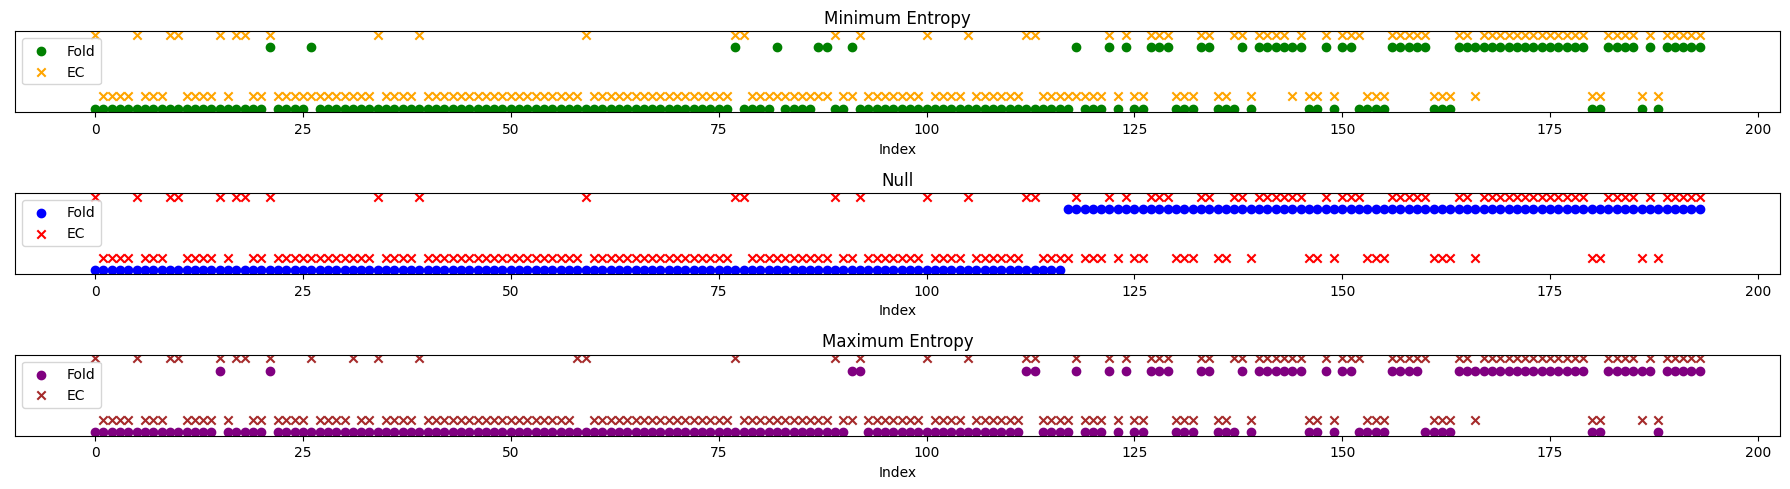

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




# 创建一个1x3的绘图区域，并调整布局
fig, axs = plt.subplots(3, 1, figsize=(18, 5))

# 偏移量
offset = 0.1

# 绘制第一个散点图，x轴为index，y轴为col1和col2的值
axs[1].scatter(df_sorted.index, df_sorted['col1'] - offset, label='Fold', c='blue', marker='o')
axs[1].scatter(df_sorted.index, df_sorted['col2'] + offset, label='EC', c='red', marker='x')
axs[1].set_title('Null')
axs[1].set_xlabel('Index')
axs[1].set_yticks([])
#axs[0].set_ylim(-0.5, 1.5)  # 设置 y 轴的范围以更好地显示分类值
axs[1].legend()

# 绘制第二个散点图，x轴为index，y轴为col3和col4的值
axs[0].scatter(df_sorted.index, df_sorted['col3'] - offset, label='Fold', c='green', marker='o')
axs[0].scatter(df_sorted.index, df_sorted['col4'] + offset, label='EC', c='orange', marker='x')
axs[0].set_title('Minimum Entropy')
axs[0].set_xlabel('Index')
axs[0].set_yticks([])
#axs[1].set_ylim(-0.5, 1.5)  # 设置 y 轴的范围以更好地显示分类值
axs[0].legend()

# 绘制第三个散点图，x轴为index，y轴为col5和col6的值
axs[2].scatter(df_sorted.index, df_sorted['col5'] - offset, label='Fold', c='purple', marker='o')
axs[2].scatter(df_sorted.index, df_sorted['col6'] + offset, label='EC', c='brown', marker='x')
axs[2].set_title('Maximum Entropy')
axs[2].set_xlabel('Index')
axs[2].set_yticks([])
#axs[2].set_ylim(-0.5, 1.5)  # 设置 y 轴的范围以更好地显示分类值
axs[2].legend()

# 调整布局
plt.tight_layout()
plt.show()


In [172]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
B = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])

# 计算每个向量的平均值
mean_A = np.mean(A, axis=0)
mean_B = np.mean(B, axis=1)

In [173]:
def cro_sim(key, ec, fold):
    Var1 = []
    Var2 = []
    for item in fun_fold[key]:
        Var1.append(load_proVec(item,ec))
        Var2.append(load_proVec(item,fold))
    Mutual_Infor = ?
    return clusterProvec

array([4., 5., 6.])

In [35]:
test_file = open('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/new.txt','r')
test_data = []
for line in test_file:
    test_data.append(line.split('\n')[0])


In [36]:
file1 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/uniprotkb_AND_reviewed_true_2023_07_03.tsv'
file3 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/all_cluster.tsv'
file4 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/afall_ID50_cluster.tsv'
file5 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/select_cluster.tsv'
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [37]:
rep_seq = {}
rep_fold = {}
seqfile = open(file3,'r')
for line in seqfile:
    key = line.split('\t')[0]
    if key in rep_seq.keys():
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
    else:
        rep_seq[key] = []
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])

foldfile = open(file5,'r')
for line in foldfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_fold.keys():
        rep_fold[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_fold[key] = []
        rep_fold[key].append(line.split('\t')[1].split('.')[0])
import os
import numpy as np
def get_pLDDT(pdb_p):
    infile = open(pdb_p,'r')
    pLDDT = []
    for line in infile:
          if line[0:6].rstrip() == 'ATOM' and line[13:15].rstrip() == 'CA':
            pLDDT.append(float(line[60:65].rstrip()))
    infile.close()
    return np.mean(pLDDT)
af_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/afall/'
af_list = os.listdir(af_path)
rep_structure = []
rep_pLDDT = []
keys = []
for key in rep_seq.keys():
    pLDDTs = []
    items = []
    for item in rep_seq[key]:
        item_name = item + '.pdb'
        if item_name in af_list:
            pdb_p = af_path+ item + '.pdb'
            pLDDTs.append(get_pLDDT(pdb_p))
            items.append(item)
    if len(pLDDTs)>0:
        max_plddt = max(pLDDTs)
        rep_pLDDT.append(max_plddt)
        rep_structure.append(items[pLDDTs.index(max_plddt)])
        keys.append(key)

threshold_value = 90
positions = [index for index, value in enumerate(rep_pLDDT) if value > threshold_value]

sel_struc=[rep_structure[index ] for index in positions]
sel_keys = [keys[index] for index in positions]

fun_fold = {}
sort_items = []
sel_seq = {}
for key in rep_fold.keys():
    fun_fold[key] = []

    for item in rep_fold[key]:
        if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            fun_fold[key].extend(rep_seq[k])
            sel_seq[k] = rep_seq[k]

            sort_items.extend(rep_seq[k])
        #print(key,item,len(sort_items))
        if item not in sel_struc and len(rep_fold[key])==1:
            fun_fold[key].append(key)
            sort_items.append(key)


In [40]:
fun_check = {}
fun_key = {}
fold_index = []
fold_items = []
for key in fun_fold.keys():
    fun_key[key] = id_ec[key]
    fun_check[key]= []
    for item in fun_fold[key]:
        fun_check[key].append(id_ec[item])
        fold_index.append(key)
        fold_items.append(item)

fun_clu = {}
for key in ec_id.keys():
    fun_clu[key] = []
    for item in ec_id[key]:
        if item in fold_items:
            fun_clu[key].append(fold_index[fold_items.index(item)])
    if len(fun_clu[key]) == 0:
        fun_clu.pop(key, None)


uni_fold = []
for key in fun_clu.keys():
    list_of_lists=fun_clu[key]
    uni_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

uni_fun = []
for key in fun_check.keys():
    list_of_lists=fun_check[key]
    uni_fun.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))




In [ ]:
set(fun_clu['1.3.5.4'])

{'P0C278', 'P17412', 'P20921'}

In [ ]:
len(ec_id['1.3.5.1'])

74

In [ ]:
set(fun_clu['1.3.5.1'])

{'P20921', 'Q8KHZ8'}

In [ ]:
fun_check['Q8KHZ8']

In [41]:
fun_check_fold = {}
fun_key_fold = {}
fold_index_fold = []
fold_items_fold = []
for key in rep_fold.keys():
    fun_key_fold[key] = id_ec[key]
    fun_check_fold[key]= []
    for item in rep_fold[key]:
        fun_check_fold[key].append(id_ec[item])
        fold_index_fold.append(key)
        fold_items_fold.append(item)

uni_fun_fold = []
for key in fun_check_fold.keys():
    list_of_lists=fun_check_fold[key]
    uni_fun_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

sel_seq = {}
for item in sel_struc:
    k = sel_keys[sel_struc.index(item)]
    sel_seq[k] = rep_seq[k]

members = []
keys = []
for key in sel_seq.keys():
    keys.append(key)
    members.append(len(sel_seq[key]))

sing_seq = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in rep_fold.keys():
    keys.append(key)
    members.append(len(rep_fold[key]))
sing_fold = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
sing_funfold = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in fun_clu.keys():
    keys.append(key)
    members.append(len(fun_clu[key]))
sing_fold_fun = [keys[index] for index, value in enumerate(members) if value == 1]

keys = []
for key in fun_check_fold.keys():
    keys.append(key)
uni_fun_fold_keys = []
uni_nofun_fold_keys = []
for i in range(len(keys)):
    if uni_fun[i]:
        uni_fun_fold_keys.append(keys[i])
    else:
        uni_nofun_fold_keys.append(keys[i])

In [42]:
file_pre = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/new_foldseek_key_cluster.tsv'
rep_pre = {}

seqfile = open(file_pre,'r')
for line in seqfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_pre.keys():
        rep_pre[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_pre[key] = []
        rep_pre[key].append(line.split('\t')[1].split('.')[0])



In [ ]:
len(fun_check_pre)

2276

In [45]:
keys = []
for key in fun_fold.keys():
    keys.append(key)

keys_pre = []
items_pre = []
for key in rep_pre.keys():
    for item in rep_pre[key]:
        keys_pre.append(key)
        items_pre.append(item)

fun_che = {}
for key in keys:
    if keys_pre[items_pre.index(key)] in fun_che.keys():
        fun_che.pop(keys_pre[items_pre.index(key)])
    else:
        fun_che[keys_pre[items_pre.index(key)]] = key


fun_check_pre = {

}
fun_keys_local = {}
for item in items_pre :
    if item in uni_nofun_fold_keys: #or item in uni_nofun_fold_keys:
        if keys_pre[items_pre.index(item)] in fun_che.keys():
            fun_check_pre[keys_pre[items_pre.index(item)]]=id_ec[item]
            fun_keys_local[keys_pre[items_pre.index(item)]]= item

test_file = open('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/new.txt','r')
test_data = []
for line in test_file:
    test_data.append(line.split('\n')[0])

test_pre = {}
y_pre = []
test_true = {}
y_true = []
keys_test = []
items_unstru = []
test_local = {}
singletons = []
for item in test_data:
    if item in items_pre:
        if keys_pre[items_pre.index(item)] in fun_check_pre.keys():
            keys_test.append(keys_pre[items_pre.index(item)])
            test_pre[item] = fun_check_pre[keys_pre[items_pre.index(item)]]
            y_pre.append(fun_check_pre[keys_pre[items_pre.index(item)]])
            test_true[item] = id_ec_test[item]
            y_true.append(id_ec_test[item])
            test_local[item] = fun_keys_local[keys_pre[items_pre.index(item)]]
            if fun_keys_local[keys_pre[items_pre.index(item)]] in sing_funfold:
                singletons.append(item)
        else:
            items_unstru.append(item)

In [ ]:
len(singletons)

15

In [ ]:
len(Uni_test_key)

134

In [ ]:
Uni_test_key = []
for key in test_local.keys():
    if test_local[key] in  uni_nofun_fold_keys:
        if id_ec_test[key] in fun_check[test_local[key]]:
            Uni_test_key.append(key)

In [ ]:

import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/test_local.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for key, value in test_local.items():
        #print(key, value)
        hf.create_dataset(key, data=value)

In [ ]:
import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/test_local.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for key, value in test_local.items():
        #print(key, value)
        hf.create_dataset(key, data=value)

In [ ]:
len(items_pre)

3675

In [ ]:
len(fun_keys_local)

3265

In [ ]:
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec_test, ec_id_test =  get_ec_id_dict(dirs+'data/new' + '.csv')
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

fun_fold_index = {}
i = 0
for key in fun_fold.keys():
    i+=1
    fun_fold_index[key] = i
EC_index = {}
j = 0
for ec in ec_id.keys():
    j+=1
    EC_index[ec] = j


In [ ]:
rep_fold['P20921']

['P20921', 'P08066', 'P48933', 'P80480', 'Q59662', 'Q8ZQU2', 'Q9ZMP1']

In [ ]:
fun_fold['P20921']

In [ ]:
fun_check['P20921']

In [ ]:
ec_id.keys()

In [ ]:
keys_fun = []
items_fun = []
for key in fun_fold.keys():
    for item in fun_fold[key]:
        keys_fun.append(key)
        items_fun.append(item)

In [ ]:
disen_data = {}
for ec in ec_id.keys():

    for item in ec_id[ec]:
        if item in items_fun:
                if item not in disen_data.keys():
                    disen_data[item] = [[fun_fold_index[keys_fun[items_fun.index(item)]], EC_index[ec], 1]]
                else:
                    disen_data[item].append([fun_fold_index[keys_fun[items_fun.index(item)]], EC_index[ec], 1])



In [ ]:
disen_data_int = {}
for key in disen_data.keys():
    i = 0
    for item in disen_data[key]:
        keys = key +'.'+str(i)
        disen_data_int[keys] = item
        i =+1

In [ ]:
import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/Disen_trainData_Labels_int.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for key, value in disen_data_int.items():
        #print(key, value)
        hf.create_dataset(key, data=value)

In [ ]:
disen_data_test = {}
for ec in ec_id_test.keys():

    for item in ec_id_test[ec]:
        if item in items_pre :
            if keys_pre[items_pre.index(item)] in fun_check_pre.keys():
                if item not in disen_data_test.keys():
                    disen_data_test[item] = [[fun_fold_index[fun_keys_local[keys_pre[items_pre.index(item)]]], EC_index[ec], 1]]
                else:
                    disen_data_test[item].append([fun_fold_index[fun_keys_local[keys_pre[items_pre.index(item)]]], EC_index[ec], 1])



In [ ]:
disen_data_test

In [ ]:
disen_data_test_int = {}
for key in disen_data_test.keys():
    i = 0
    for item in disen_data_test[key]:
        keys = key +'.'+str(i)
        disen_data_test_int[keys] = item
        i =+1

In [ ]:
disen_data_test_int

In [ ]:
import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/Disen_testData_Labels_int.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for key, value in disen_data_test_int.items():
        #print(key, value)
        hf.create_dataset(key, data=value)


In [ ]:
import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/Fun_fold.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for i in range(len(items_fun)):
        #print(key, value)
        hf.create_dataset(items_fun[i], data=keys_fun[i])


In [ ]:
EC_counts = []
EC_counts_len = []
for item in y_true:
    EC_counts.extend(item)
    EC_counts_len.append(len(item))

In [ ]:
# 原始列表
versions = ['4.2.3.115', '4.2.3.114', '4.2.3.15', '4.2.3.113']

# 定义一个自定义的排序函数，按照版本号的逻辑进行排序
def custom_sort(version):
    return tuple(map(int, version.split('.')))

# 对列表进行排序，并使用自定义的排序函数
sorted_versions = sorted(versions, key=custom_sort)

# 打印排序后的结果
print("Sorted Versions:", str(sorted_versions))


Sorted Versions: ['4.2.3.15', '4.2.3.113', '4.2.3.114', '4.2.3.115']


In [ ]:
true_labels_full

In [ ]:
id_ec_test, ec_id_test =  get_ec_id_dict(dirs+'data/new' + '.csv')
Pos_pre = []
true_labels = []
pred_labels = []
true_labels_full = []
pred_labels_full = []

for key in test_pre.keys():
    true_labels_full.append(str(sorted(test_true[key], key=custom_sort)))
    true_labels.append(1)
    pred_labels_full.append(str(sorted(test_pre[key], key=custom_sort)))
    if test_pre[key] == test_true[key]:
        Pos_pre.append(key)
        pred_labels.append(1)
    else:
        pred_labels.append(0)

In [ ]:
true_labels_rou = []
pred_labels_rou = []

for key in test_pre.keys():

    true_labels_rou.append(1)

    if len(set(test_pre[key]).intersection(set(test_true[key]))) > 0:
        Pos_pre.append(key)
        pred_labels_rou.append(1)
    else:
        pred_labels_rou.append(0)

In [ ]:
len(pred_labels_rou)

241

In [ ]:
len(true_labels_rou)

241

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


f1 = f1_score(true_labels_rou, pred_labels_rou, average='weighted')
# 计算精确度
precision = precision_score(true_labels_rou, pred_labels_rou)

# 计算召回率
recall = recall_score(true_labels_rou, pred_labels_rou)

# 计算 F1 分数
#f1 = f1_score(true_labels_rou, pred_labels_rou)

# 计算准确率
accuracy = accuracy_score(true_labels_rou, pred_labels_rou)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

Precision: 1.0
Recall: 0.16923076923076924
F1 Score: 0.2894736842105263
Accuracy: 0.16923076923076924


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


f1 = f1_score(true_labels_full, pred_labels_full, average='weighted')
# 计算精确度
precision = precision_score(true_labels, pred_labels)

# 计算召回率
recall = recall_score(true_labels, pred_labels)

# 计算 F1 分数
#f1 = f1_score(true_labels, pred_labels)

# 计算准确率
accuracy = accuracy_score(true_labels_full, pred_labels_full)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

Precision: 1.0
Recall: 0.22406639004149378
F1 Score: 0.21933771622568307
Accuracy: 0.22406639004149378
